# A06 — Keras Vanilla RNN dự báo hành vi mua hàng

Notebook này huấn luyện baseline Keras cho đúng bài toán đã khóa:

$$
\underbrace{8\ \text{tuần hành vi trước} \times 5\ \text{đặc trưng}}_{X}
\longrightarrow
\underbrace{\text{có mua trong tuần kế tiếp hay không}}_{y \in \{0,1\}}.
$$

Mục tiêu là triển khai `SimpleRNN` có ý nghĩa tương đương baseline PyTorch, không thay đổi dữ liệu và chưa kết luận framework nào tốt hơn. Notebook chỉ đọc ba artifact dùng chung; không tạo sequence, không chia lại split và không fit lại scaler.

## 1. Thiết lập tái lập

`SEED = 42` được áp dụng cho Python, NumPy và TensorFlow/Keras. Deterministic operations được yêu cầu khi runtime hỗ trợ; điều này giúp giảm dao động trong cùng môi trường nhưng không hứa hẹn kết quả bit-for-bit giữa phần cứng hoặc phiên bản thư viện khác nhau.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import random
import sys
import time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve
import tensorflow as tf
from tensorflow import keras

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.keras_customer import (
    binary_classification_metrics,
    build_callbacks,
    build_customer_rnn,
    compute_class_weight,
    make_sample_weights,
    validate_customer_arrays,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

METADATA_PATH = ROOT / "results" / "metrics" / "preprocessing_metadata.json"
PYTORCH_METRICS_PATH = ROOT / "results" / "metrics" / "pytorch_customer_metrics.json"
MODEL_PATH = ROOT / "models" / "keras" / "keras_customer_rnn_best.keras"
METRICS_PATH = ROOT / "results" / "metrics" / "keras_customer_metrics.json"
PREDICTIONS_PATH = ROOT / "results" / "predictions" / "keras_customer_predictions.csv"
FIGURE_DIR = ROOT / "results" / "figures" / "keras_customer"

for directory in (MODEL_PATH.parent, METRICS_PATH.parent, PREDICTIONS_PATH.parent, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

devices = tf.config.list_physical_devices()
device_label = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print(f"Project root: {ROOT}")
print(f"TensorFlow: {tf.__version__} | Keras: {keras.__version__} | device: {device_label} | seed: {SEED}")

Project root: C:\DATA\assign\A06
TensorFlow: 2.21.0 | Keras: 3.15.1 | device: CPU | seed: 42


## 2. Nạp đúng dữ liệu dùng chung và kiểm tra phép so sánh công bằng

Mỗi NPZ phải chứa đúng `X`, `y`, `customer_id`, `target_week`. Checksum được đối chiếu với metadata tiền xử lý, shape phải là `(samples, 8, 5)`, và ranh giới `target_week` phải theo thứ tự TRAIN → validation → TEST.

Năm feature theo thứ tự cố định là `total_spent`, `total_quantity`, `order_count`, `unique_products`, `active_flag`. `CustomerID` và `target_week` chỉ phục vụ truy vết, hoàn toàn không đi vào tensor đầu vào.

In [2]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
pytorch_metrics = json.loads(PYTORCH_METRICS_PATH.read_text(encoding="utf-8"))
customer_meta = metadata["customer"]

assert metadata["seed"] == pytorch_metrics["seed"] == SEED
assert customer_meta["sequence_length"] == 8
assert customer_meta["feature_names"] == pytorch_metrics["data"]["feature_names"]
assert pytorch_metrics["evaluation"]["threshold"] == 0.5

required_keys = {"X", "y", "customer_id", "target_week"}
artifacts = {}
artifact_hashes = {}
for split in ("train", "val", "test"):
    info = customer_meta["artifacts"][split]
    path = ROOT / info["path"]
    actual_hash = sha256(path)
    assert actual_hash == info["sha256"], f"Checksum sai: {path}"
    with np.load(path) as loaded:
        assert set(loaded.files) == required_keys
        artifacts[split] = {name: loaded[name].copy() for name in loaded.files}
    validate_customer_arrays(artifacts[split]["X"], artifacts[split]["y"])
    weeks = artifacts[split]["target_week"]
    assert np.all(weeks[1:] >= weeks[:-1])
    artifact_hashes[split] = actual_hash

assert artifacts["train"]["target_week"][-1] < artifacts["val"]["target_week"][0]
assert artifacts["val"]["target_week"][-1] < artifacts["test"]["target_week"][0]

rows = []
for split, data in artifacts.items():
    counts = np.bincount(data["y"].astype(int), minlength=2)
    rows.append(
        {
            "split": split.upper(),
            "X shape": str(data["X"].shape),
            "class 0": int(counts[0]),
            "class 1": int(counts[1]),
            "% positive": 100 * counts[1] / counts.sum(),
            "tuần đầu": str(data["target_week"][0]),
            "tuần cuối": str(data["target_week"][-1]),
        }
    )
pd.DataFrame(rows).set_index("split").round({"% positive": 2})

,X shape,class 0,class 1,% positive,tuần đầu,tuần cuối
split,,,,,,
TRAIN,"(247458, 8, 5)",231206,16252,6.57,2010-02-01,2011-07-11
VAL,"(50354, 8, 5)",47893,2461,4.89,2011-07-18,2011-09-19
TEST,"(53052, 8, 5)",49345,3707,6.99,2011-09-26,2011-11-28


## 3. Mất cân bằng lớp và class weight

Chỉ khoảng 5–7% mẫu thuộc lớp mua hàng. Accuracy vì thế có thể cao ngay cả khi mô hình gần như luôn dự đoán lớp 0; Precision, Recall, F1 và ROC-AUC phải được xem cùng nhau.

PyTorch đã dùng `positive_weight = n_negative / n_positive`, tính **chỉ từ TRAIN**. Keras dùng cơ chế tương đương qua `class_weight={0: 1, 1: positive_weight}` trong `fit()`. Validation và TEST không tham gia tính trọng số.

In [3]:
class_weight = compute_class_weight(artifacts["train"]["y"])
expected_positive_weight = customer_meta["class_weight"]["positive_weight"]
pytorch_positive_weight = pytorch_metrics["class_weighting"]["positive_weight"]
assert np.isclose(class_weight[1], expected_positive_weight)
assert np.isclose(class_weight[1], pytorch_positive_weight)

train_counts = np.bincount(artifacts["train"]["y"].astype(int), minlength=2)
print(f"TRAIN class 0: {train_counts[0]:,}")
print(f"TRAIN class 1: {train_counts[1]:,}")
print(f"class_weight = {class_weight}")

TRAIN class 0: 231,206
TRAIN class 1: 16,252
class_weight = {0: 1.0, 1: 14.226310607925178}


## 4. Keras `SimpleRNN` và sự tương ứng với PyTorch

Hai baseline có cùng ý tưởng:

| PyTorch | Keras | Vai trò |
|---|---|---|
| `nn.RNN(input_size=5, hidden_size=64, batch_first=True)` | `SimpleRNN(64, input_shape=(8, 5))` | Đọc 8 time steps và tạo hidden state cuối |
| `Linear(64, 1)` | `Dense(1, activation="sigmoid")` | Biến hidden state thành đầu ra nhị phân |
| một logit + `BCEWithLogitsLoss` | xác suất sigmoid + `binary_crossentropy` | Tối ưu binary cross-entropy theo cách ổn định của từng framework |

Input Keras có shape `(batch_size, 8, 5)`. `SimpleRNN(64)` trả về hidden state cuối có 64 phần tử cho mỗi sequence vì mặc định `return_sequences=False`. `Dense` và sigmoid chuyển nó thành xác suất mua hàng trong `[0, 1]`.

Số tham số không hoàn toàn bằng PyTorch vì hai framework biểu diễn bias trong RNN khác nhau; đây không phải thay đổi về vai trò của baseline.

In [4]:
HIDDEN_UNITS = 64
LEARNING_RATE = 1e-3
model = build_customer_rnn(
    input_shape=(8, 5),
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
)
parameter_count = model.count_params()
model.summary()

demo_output = model(artifacts["train"]["X"][:4], training=False).numpy().ravel()
print("Demo input:", artifacts["train"]["X"][:4].shape, "-> probability shape:", demo_output.shape)
print("Trainable parameters:", f"{parameter_count:,}")
assert parameter_count == 4545

Model: "keras_customer_vanilla_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ purchase_probability (Dense)    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

Demo input: (4, 8, 5) -> probability shape: (4,)
Trainable parameters: 4,545


## 5. `fit()`, binary cross-entropy và EarlyStopping

`model.fit()` lặp qua mini-batch TRAIN, tính binary cross-entropy và dùng Adam để cập nhật trọng số. `validation_data` chỉ đo `val_loss`; nó không được dùng để cập nhật gradient. Để tương ứng với PyTorch, validation loss dùng lại đúng hai trọng số lớp đã tính từ TRAIN (không tính lại từ validation).

`EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)` dừng khi validation loss không còn cải thiện đủ lâu và khôi phục trọng số tốt nhất. `ModelCheckpoint` đồng thời lưu mô hình có validation loss thấp nhất dưới định dạng `.keras`. TEST chưa được dùng ở giai đoạn này.

In [5]:
BATCH_SIZE = 1024
MAX_EPOCHS = 30
PATIENCE = 5
MIN_DELTA = 1e-4

callbacks = build_callbacks(MODEL_PATH, patience=PATIENCE, min_delta=MIN_DELTA)
validation_sample_weight = make_sample_weights(artifacts["val"]["y"], class_weight)
start_time = time.perf_counter()
history = model.fit(
    artifacts["train"]["X"],
    artifacts["train"]["y"],
    validation_data=(
        artifacts["val"]["X"],
        artifacts["val"]["y"],
        validation_sample_weight,
    ),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)
training_duration_seconds = time.perf_counter() - start_time
epochs_actually_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_validation_loss = float(np.min(history.history["val_loss"]))

# ModelCheckpoint lưu raw minimum val_loss; nạp lại trước lần đánh giá TEST duy nhất.
model = keras.models.load_model(MODEL_PATH)

print(
    f"Đã chạy {epochs_actually_run} epoch; best epoch={best_epoch}; "
    f"best val_loss={best_validation_loss:.6f}; thời gian={training_duration_seconds:.2f}s"
)

Epoch 1/30


242/242 - 7s - 29ms/step - loss: 1.1513 - val_loss: 0.9697


Epoch 2/30


242/242 - 4s - 16ms/step - loss: 1.1399 - val_loss: 0.9692


Epoch 3/30


...

Epoch 18/30


242/242 - 4s - 18ms/step - loss: 1.1332 - val_loss: 0.9599


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 13.


Đã chạy 18 epoch; best epoch=16; best val_loss=0.959909; thời gian=86.01s


## 6. Train/validation loss

Loss dưới đây là binary cross-entropy có class weighting. TRAIN loss và validation loss đều phản ánh mục tiêu có trọng số, nhưng chỉ validation loss quyết định checkpoint. Đường loss dùng để chẩn đoán quá trình học, không phải metric cuối cùng của classification.

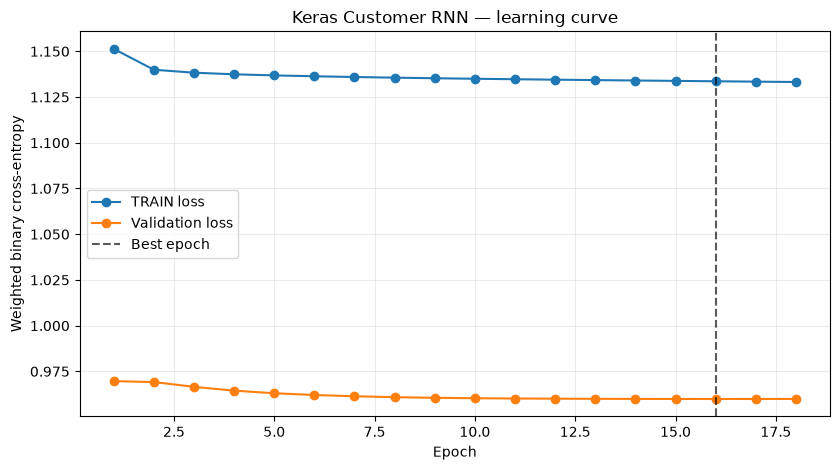

In [6]:
epochs = np.arange(1, epochs_actually_run + 1)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(epochs, history.history["loss"], marker="o", label="TRAIN loss")
ax.plot(epochs, history.history["val_loss"], marker="o", label="Validation loss")
ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.65, label="Best epoch")
ax.set(title="Keras Customer RNN — learning curve", xlabel="Epoch", ylabel="Weighted binary cross-entropy")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
loss_figure_path = FIGURE_DIR / "training_validation_loss.png"
fig.savefig(loss_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 7. `predict()` và đánh giá TEST một lần

Sau khi validation đã chọn mô hình, `predict()` tạo một xác suất cho mỗi sequence TEST. Threshold được cố định ở `0.5`, giống PyTorch; threshold không được điều chỉnh từ TEST.

- **Accuracy:** tỷ lệ dự đoán đúng, nhưng dễ gây hiểu nhầm khi lớp 0 áp đảo.
- **Precision:** trong các mẫu dự đoán mua, bao nhiêu mẫu thực sự mua.
- **Recall:** trong các mẫu thực sự mua, mô hình tìm được bao nhiêu.
- **F1-score:** trung bình điều hòa giữa Precision và Recall.
- **ROC-AUC:** khả năng xếp xác suất của mẫu dương cao hơn mẫu âm trên mọi threshold.

In [7]:
THRESHOLD = 0.5
test_probability = model.predict(
    artifacts["test"]["X"], batch_size=BATCH_SIZE, verbose=0
).ravel()
test_true = artifacts["test"]["y"].astype(np.int8)
test_predicted = (test_probability >= THRESHOLD).astype(np.int8)
test_metrics = binary_classification_metrics(
    test_true, test_probability, threshold=THRESHOLD
)
test_confusion = confusion_matrix(test_true, test_predicted, labels=[0, 1])

metric_table = pd.DataFrame(
    {"Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
     "Value": [test_metrics["accuracy"], test_metrics["precision"], test_metrics["recall"], test_metrics["f1"], test_metrics["roc_auc"]]}
).set_index("Metric")
metric_table.round(4)

,Value
Metric,
Accuracy,0.7600
Precision,0.1594
Recall,0.5697
F1-score,0.2491
ROC-AUC,0.7005


## 8. Confusion matrix

Ma trận nhầm lẫn cho biết riêng TN, FP, FN và TP tại threshold 0,5. Với dữ liệu mất cân bằng, đây là cách nhìn trực tiếp hơn so với chỉ báo cáo Accuracy.

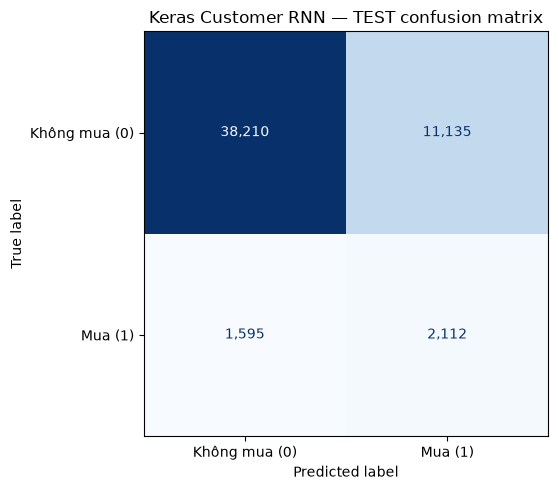

In [8]:
fig, ax = plt.subplots(figsize=(5.6, 5.0))
display = ConfusionMatrixDisplay(test_confusion, display_labels=["Không mua (0)", "Mua (1)"])
display.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",d")
ax.set_title("Keras Customer RNN — TEST confusion matrix")
fig.tight_layout()
confusion_figure_path = FIGURE_DIR / "test_confusion_matrix.png"
fig.savefig(confusion_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 9. ROC curve

ROC curve quét qua nhiều threshold và biểu diễn đánh đổi giữa true-positive rate và false-positive rate. Đường chéo là mức xếp hạng ngẫu nhiên; AUC tóm tắt diện tích dưới đường cong. ROC-AUC không thay thế Precision/Recall tại threshold triển khai.

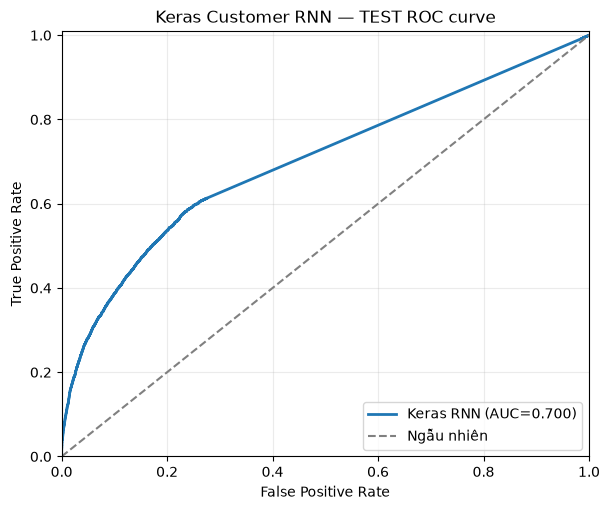

In [9]:
false_positive_rate, true_positive_rate, _ = roc_curve(test_true, test_probability)
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.plot(false_positive_rate, true_positive_rate, linewidth=2, label=f"Keras RNN (AUC={test_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ngẫu nhiên")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="Keras Customer RNN — TEST ROC curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
roc_figure_path = FIGURE_DIR / "test_roc_curve.png"
fig.savefig(roc_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 10. Lưu predictions và metadata thí nghiệm

Mỗi prediction giữ nguyên `CustomerID` và `target_week` để truy vết, nhưng hai trường này không phải feature. JSON sử dụng cấu trúc gần với artifact PyTorch: kiến trúc, dữ liệu, huấn luyện, class weighting, đánh giá và đường dẫn artifact.

In [10]:
predictions = pd.DataFrame(
    {
        "CustomerID": artifacts["test"]["customer_id"],
        "target_week": artifacts["test"]["target_week"].astype(str),
        "true_label": test_true,
        "probability": test_probability,
        "predicted_label": test_predicted,
    }
)
assert not predictions.isna().any().any()
assert not predictions.duplicated(["CustomerID", "target_week"]).any()
predictions.to_csv(PREDICTIONS_PATH, index=False)

model_hash = sha256(MODEL_PATH)
predictions_hash = sha256(PREDICTIONS_PATH)
metrics_payload = {
    "experiment": "Keras Customer Vanilla RNN",
    "seed": SEED,
    "device": device_label.lower(),
    "framework_versions": {"tensorflow": tf.__version__, "keras": keras.__version__},
    "architecture": {
        "recurrent_layer": "keras.layers.SimpleRNN",
        "input_size": 5,
        "sequence_length": 8,
        "hidden_units": HIDDEN_UNITS,
        "num_layers": 1,
        "activation": "tanh",
        "head": "Dense(1, activation='sigmoid') producing one probability",
        "parameter_count": parameter_count,
    },
    "data": {
        "feature_names": customer_meta["feature_names"],
        "split_shapes": {split: list(data["X"].shape) for split, data in artifacts.items()},
        "source_artifacts": customer_meta["artifacts"],
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "criterion": "binary_crossentropy",
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "restore_best_weights": True,
        "validation_weighting": "sample weights mapped from TRAIN-derived class_weight",
        "epochs_actually_run": epochs_actually_run,
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,
        "training_duration_seconds": training_duration_seconds,
        "selection_scope": "validation loss only; TEST unused until final evaluation",
        "history": {
            "train_loss": [float(value) for value in history.history["loss"]],
            "validation_loss": [float(value) for value in history.history["val_loss"]],
        },
    },
    "class_weighting": {
        "used": True,
        "type": "Keras class_weight passed to fit()",
        "class_0_weight": class_weight[0],
        "positive_weight": class_weight[1],
        "formula": "TRAIN negatives / TRAIN positives",
        "fit_scope": "TRAIN y only",
        "train_class_0": int(train_counts[0]),
        "train_class_1": int(train_counts[1]),
    },
    "evaluation": {
        "split": "TEST",
        "evaluations_on_test": 1,
        "threshold": THRESHOLD,
        "metrics": test_metrics,
        "confusion_matrix_tn_fp_fn_tp": {
            "tn": int(test_confusion[0, 0]),
            "fp": int(test_confusion[0, 1]),
            "fn": int(test_confusion[1, 0]),
            "tp": int(test_confusion[1, 1]),
        },
    },
    "artifacts": {
        "model": {"path": str(MODEL_PATH.relative_to(ROOT)).replace("\\", "/"), "sha256": model_hash},
        "predictions": {"path": str(PREDICTIONS_PATH.relative_to(ROOT)).replace("\\", "/"), "rows": len(predictions), "sha256": predictions_hash},
        "figures": [
            str(path.relative_to(ROOT)).replace("\\", "/")
            for path in (loss_figure_path, confusion_figure_path, roc_figure_path)
        ],
    },
}
METRICS_PATH.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Đã lưu model -> {MODEL_PATH.relative_to(ROOT)}")
print(f"Đã lưu {len(predictions):,} predictions -> {PREDICTIONS_PATH.relative_to(ROOT)}")
print(f"Đã lưu metrics -> {METRICS_PATH.relative_to(ROOT)}")
predictions.head()

Đã lưu model -> models\keras\keras_customer_rnn_best.keras
Đã lưu 53,052 predictions -> results\predictions\keras_customer_predictions.csv
Đã lưu metrics -> results\metrics\keras_customer_metrics.json


,CustomerID,target_week,true_label,probability,predicted_label
0,12346,2011-09-26,0,0.322627,0
1,12347,2011-09-26,0,0.647614,1
2,12348,2011-09-26,0,0.317189,0
3,12349,2011-09-26,0,0.322627,0
4,12350,2011-09-26,0,0.322627,0


## 11. Kiểm tra artifact đầu ra

Kiểm tra cuối xác nhận model có thể nạp lại, CSV có đúng schema và số dòng, xác suất hợp lệ, metrics JSON đầy đủ, ba figure tồn tại, và checksum input vẫn nguyên vẹn.

In [11]:
expected_columns = ["CustomerID", "target_week", "true_label", "probability", "predicted_label"]
assert MODEL_PATH.is_file()
assert METRICS_PATH.is_file()
assert PREDICTIONS_PATH.is_file()
assert predictions.columns.tolist() == expected_columns
assert len(predictions) == len(artifacts["test"]["y"]) == 53052
assert predictions["probability"].between(0, 1).all()
assert set(predictions["predicted_label"].unique()).issubset({0, 1})
assert all(path.is_file() for path in (loss_figure_path, confusion_figure_path, roc_figure_path))

reloaded = keras.models.load_model(MODEL_PATH)
assert reloaded.input_shape == (None, 8, 5)
assert reloaded.output_shape == (None, 1)
assert reloaded.count_params() == parameter_count

saved_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
assert saved_metrics["evaluation"]["threshold"] == 0.5
assert saved_metrics["evaluation"]["evaluations_on_test"] == 1
for name in ("accuracy", "precision", "recall", "f1", "roc_auc"):
    assert np.isfinite(saved_metrics["evaluation"]["metrics"][name])
for split, expected_hash in artifact_hashes.items():
    input_path = ROOT / customer_meta["artifacts"][split]["path"]
    assert sha256(input_path) == expected_hash

print("PASS — notebook chạy đầy đủ, model/CSV/JSON/figures hợp lệ, input không đổi.")
print("Figures:", sorted(path.name for path in FIGURE_DIR.glob("*.png")))

PASS — notebook chạy đầy đủ, model/CSV/JSON/figures hợp lệ, input không đổi.
Figures: ['test_confusion_matrix.png', 'test_roc_curve.png', 'training_validation_loss.png']


## 12. Tóm tắt

- Keras nhận cùng tensor `(samples, 8, 5)`, cùng target tuần kế tiếp và cùng split thời gian với PyTorch.
- `SimpleRNN(64)` đóng vai trò tương ứng `nn.RNN`; `Dense(1, sigmoid)` tương ứng `Linear` rồi chuyển logit thành xác suất.
- Binary cross-entropy là loss huấn luyện; class weight dương được tính duy nhất từ TRAIN.
- `fit()` dùng validation cho EarlyStopping và khôi phục mô hình tốt nhất; TEST chỉ được dự đoán một lần sau lựa chọn mô hình.
- Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrix và ROC curve cùng mô tả kết quả trên dữ liệu mất cân bằng.
- Notebook này ghi kết quả Keras độc lập. Việc so sánh và kết luận giữa framework được dành cho Notebook 08.